In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules


In [2]:
import os
print(os.getcwd())


d:\Data mining\Nhom11\notebooks


In [3]:
basket_bool = pd.read_parquet("../data/processed/basket_bool.parquet")
basket_bool.head()


,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [4]:
start = time.time()

freq_apriori = apriori(
    basket_bool,
    min_support=0.01,
    use_colnames=True
)

rules_apriori = association_rules(
    freq_apriori,
    metric="confidence",
    min_threshold=0.3
)

end = time.time()

print("Apriori time:", end - start)
print("Itemsets:", len(freq_apriori))
print("Rules:", len(rules_apriori))


Apriori time: 133.39479660987854
Itemsets: 2156
Rules: 2374


In [5]:
start = time.time()

freq_fp = fpgrowth(
    basket_bool,
    min_support=0.01,
    use_colnames=True
)

rules_fp = association_rules(
    freq_fp,
    metric="confidence",
    min_threshold=0.3
)

end = time.time()

print("FP-Growth time:", end - start)
print("Itemsets:", len(freq_fp))
print("Rules:", len(rules_fp))


FP-Growth time: 10.781038284301758
Itemsets: 2156
Rules: 2374


In [6]:
supports = [0.05, 0.03, 0.01]
results = []

for s in supports:
    # Apriori
    start_a = time.time()
    fa = apriori(
        basket_bool,
        min_support=s,
        use_colnames=True,
        low_memory=True
    )
    ra = association_rules(fa, metric="confidence", min_threshold=0.3)
    time_a = time.time() - start_a

    # FP-Growth (vẫn chạy đủ)
    start_f = time.time()
    ff = fpgrowth(
        basket_bool,
        min_support=s,
        use_colnames=True
    )
    rf = association_rules(ff, metric="confidence", min_threshold=0.3)
    time_f = time.time() - start_f

    results.append({
        "min_support": s,
        "Apriori_time": time_a,
        "FP_time": time_f,
        "Apriori_rules": len(ra),
        "FP_rules": len(rf)
    })

compare_df = pd.DataFrame(results)
compare_df


,min_support,Apriori_time,FP_time,Apriori_rules,FP_rules
0,0.05,4.373550,3.710119,0,0
1,0.03,10.675466,3.447266,21,21
2,0.01,46.204489,8.613402,2374,2374


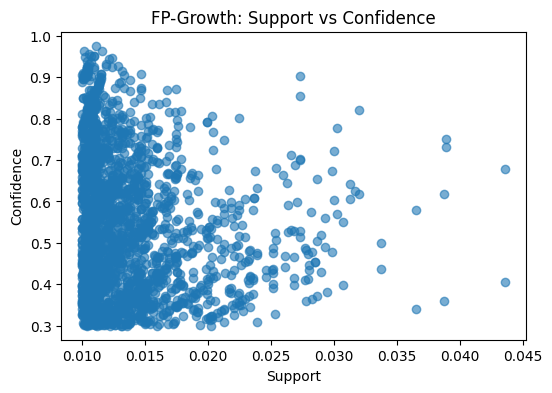

In [7]:
plt.figure(figsize=(6,4))
plt.scatter(
    rules_fp['support'],
    rules_fp['confidence'],
    alpha=0.6
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("FP-Growth: Support vs Confidence")
plt.show()


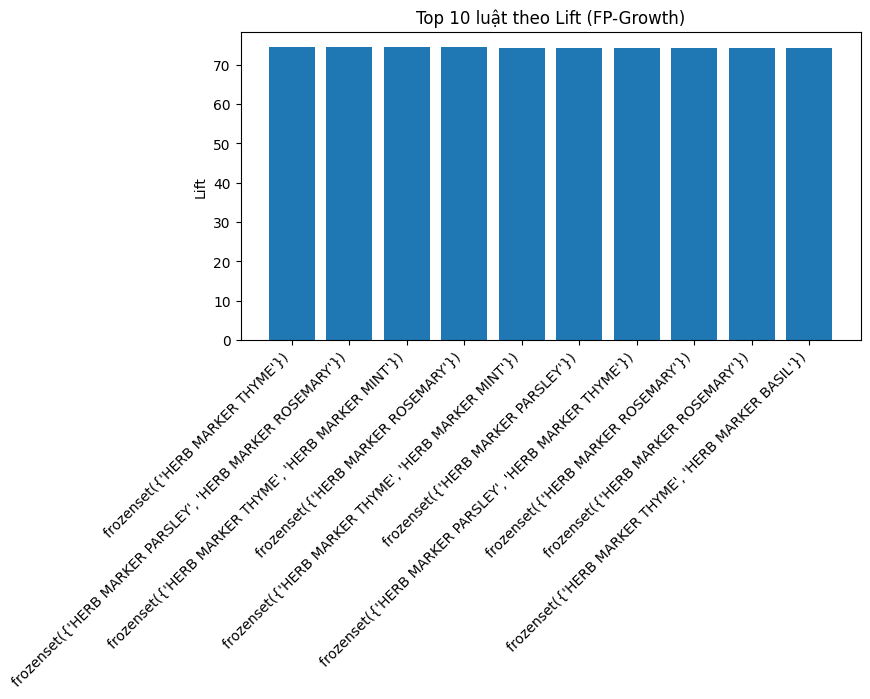

In [8]:
top_lift = rules_fp.sort_values("lift", ascending=False).head(10)

plt.figure(figsize=(8,4))
plt.bar(
    range(len(top_lift)),
    top_lift['lift']
)

plt.xticks(
    range(len(top_lift)),
    [str(x) for x in top_lift['antecedents']],
    rotation=45,
    ha='right'
)

plt.ylabel("Lift")
plt.title("Top 10 luật theo Lift (FP-Growth)")
plt.show()
